### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

In [53]:

from __future__ import absolute_import, division, print_function, unicode_literals

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

1.13.1


### Load tensorflow

In [54]:
#import tensorflow as tf
#tf.set_random_seed(42)

In [55]:
#tf.__version__

### Collect Data

In [56]:
import keras

In [57]:
#(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

In [58]:
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [59]:
print(test_labels[0:5])

[9 2 1 1 6]


### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [60]:
train_images.shape

(60000, 28, 28)

In [61]:
len(train_labels)

60000

In [62]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [63]:
test_images.shape

(10000, 28, 28)

In [64]:
len(test_labels)

10000

In [65]:
print(train_labels.shape)
print('First 5 examples now are: ', train_labels[0:5])

(60000,)
First 5 examples now are:  [9 0 0 3 0]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

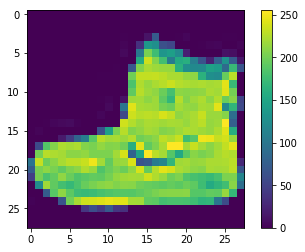

In [66]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [67]:

train_images = train_images / 255.0

test_images = test_images / 255.0

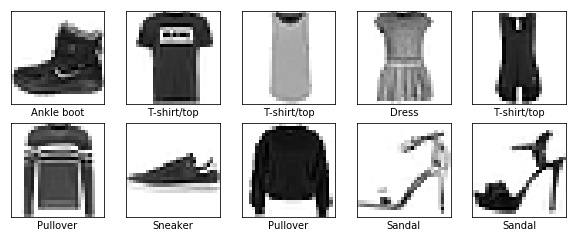

In [68]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

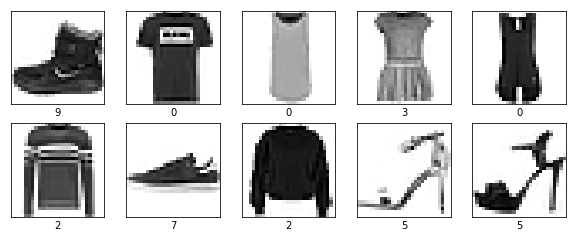

In [69]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(train_labels[i])
plt.show()

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [70]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [71]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Execute the model using model.fit()

In [72]:
model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
60000/60000 [==============================] - 10s 166us/step - loss: 0.5004 - acc: 0.8229
Epoch 2/5
60000/60000 [==============================] - 9s 143us/step - loss: 0.3770 - acc: 0.8640
Epoch 3/5
60000/60000 [==============================] - 8s 134us/step - loss: 0.3370 - acc: 0.8760
Epoch 4/5
60000/60000 [==============================] - 8s 134us/step - loss: 0.3134 - acc: 0.8845
Epoch 5/5
60000/60000 [==============================] - 8s 133us/step - loss: 0.2971 - acc: 0.8901


### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [73]:
model.fit(train_images, train_labels, epochs=5, batch_size=64)

Epoch 1/5
60000/60000 [==============================] - 5s 82us/step - loss: 0.2618 - acc: 0.9024
Epoch 2/5
60000/60000 [==============================] - 5s 84us/step - loss: 0.2566 - acc: 0.9046
Epoch 3/5
60000/60000 [==============================] - 5s 85us/step - loss: 0.2483 - acc: 0.9079
Epoch 4/5
60000/60000 [==============================] - 5s 80us/step - loss: 0.2419 - acc: 0.9097
Epoch 5/5
60000/60000 [==============================] - 5s 77us/step - loss: 0.2327 - acc: 0.9127


### Execute the model

In [74]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('Test accuracy:', test_acc)

10000/10000 [==============================] - 1s 85us/step
Test accuracy: 0.8871


In [75]:
predictions = model.predict(test_images)

In [76]:
predictions[0]
np.argmax(predictions[0])

test_labels[0]

9

In [77]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  
  plt.imshow(img, cmap=plt.cm.binary)
  
  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'
  
  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array[i], true_label[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)
  
  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

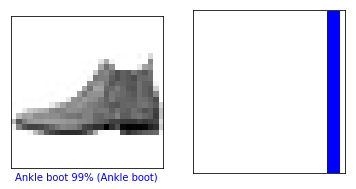

In [78]:

i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions, test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions,  test_labels)
plt.show()

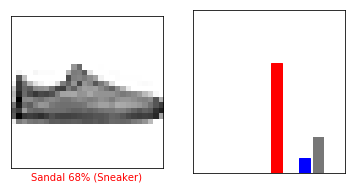

In [79]:
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions, test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions,  test_labels)
plt.show()


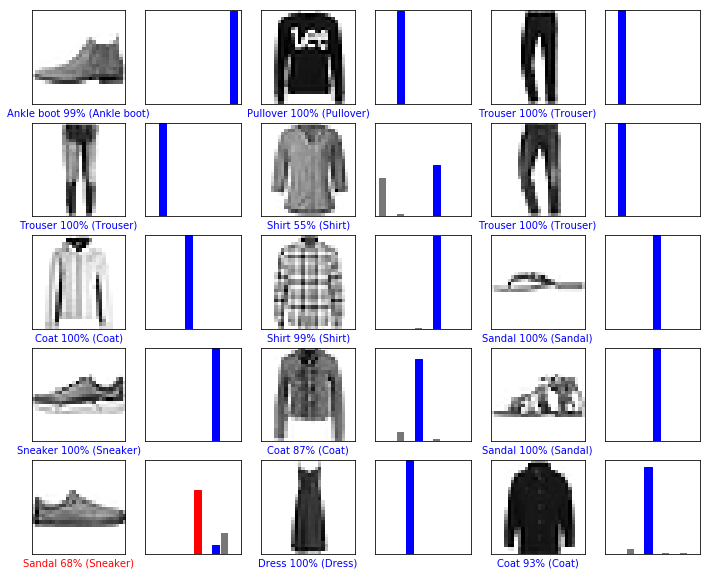

In [80]:

# Plot the first X test images, their predicted label, and the true label
# Color correct predictions in blue, incorrect predictions in red
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions, test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions, test_labels)
plt.show()

In [81]:
# Grab an image from the test dataset
img = test_images[0]

print(img.shape)

(28, 28)


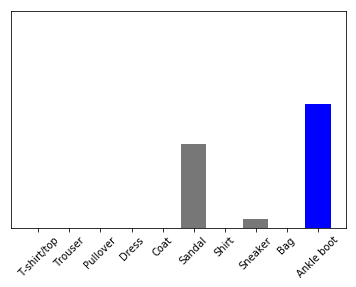

In [83]:
plot_value_array(0, predictions_single, test_labels)
plt.xticks(range(10), class_names, rotation=45)
plt.show()

In [84]:
prediction_result = np.argmax(predictions_single[0])
print(prediction_result)

9


### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [85]:
from keras import optimizers
# All parameter gradients will be clipped to
# a maximum norm of 1.
sgd = optimizers.SGD(lr=0.001, clipnorm=1.)
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [86]:
model.fit(train_images, train_labels, epochs=5, batch_size=64)

Epoch 1/5
60000/60000 [==============================] - 5s 75us/step - loss: 0.2026 - acc: 0.9253
Epoch 2/5
60000/60000 [==============================] - 4s 65us/step - loss: 0.1974 - acc: 0.9281
Epoch 3/5
60000/60000 [==============================] - 4s 69us/step - loss: 0.1955 - acc: 0.9276
Epoch 4/5
60000/60000 [==============================] - 4s 66us/step - loss: 0.1943 - acc: 0.9290
Epoch 5/5
60000/60000 [==============================] - 4s 67us/step - loss: 0.1934 - acc: 0.9295


### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [87]:
tf.keras.activations.sigmoid

<function tensorflow.python.keras.activations.sigmoid(x)>

In [88]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation=tf.nn.sigmoid),
    keras.layers.Dense(100, activation=tf.nn.sigmoid),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [89]:
from keras import optimizers
# All parameter gradients will be clipped to
# a maximum norm of 1.
sgd = optimizers.SGD(lr=0.003, clipnorm=1.)
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [90]:
model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
60000/60000 [==============================] - 7s 120us/step - loss: 2.0151 - acc: 0.4348
Epoch 2/5
60000/60000 [==============================] - 7s 111us/step - loss: 1.3367 - acc: 0.6203
Epoch 3/5
60000/60000 [==============================] - 7s 116us/step - loss: 1.0169 - acc: 0.6825
Epoch 4/5
60000/60000 [==============================] - 7s 113us/step - loss: 0.8538 - acc: 0.7222
Epoch 5/5
60000/60000 [==============================] - 7s 115us/step - loss: 0.7521 - acc: 0.7429


## Review model

In [97]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
from keras import optimizers
# All parameter gradients will be clipped to
# a maximum norm of 1.
#sgd = optimizers.SGD(lr=0.001, clipnorm=1.)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=15, batch_size=64)

Epoch 1/15
60000/60000 [==============================] - 6s 95us/step - loss: 0.5235 - acc: 0.8170
Epoch 2/15
60000/60000 [==============================] - 5s 86us/step - loss: 0.3868 - acc: 0.8633
Epoch 3/15
60000/60000 [==============================] - 5s 81us/step - loss: 0.3474 - acc: 0.8737
Epoch 4/15
60000/60000 [==============================] - 5s 82us/step - loss: 0.3237 - acc: 0.8821
Epoch 5/15
60000/60000 [==============================] - 5s 84us/step - loss: 0.3065 - acc: 0.8867
Epoch 6/15
60000/60000 [==============================] - 5s 83us/step - loss: 0.2907 - acc: 0.8938
Epoch 7/15
60000/60000 [==============================] - 5s 84us/step - loss: 0.2782 - acc: 0.8980
Epoch 8/15
60000/60000 [==============================] - 5s 83us/step - loss: 0.2679 - acc: 0.9011
Epoch 9/15
60000/60000 [==============================] - 5s 85us/step - loss: 0.2575 - acc: 0.9045
Epoch 10/15
60000/60000 [==============================] - 5s 84us/step - loss: 0.2496 - acc: 0.9077

In [98]:
model_sgd = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
from keras import optimizers
# All parameter gradients will be clipped to
# a maximum norm of 1.
sgd = optimizers.SGD(lr=0.001, clipnorm=1.)
model_sgd.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model_sgd.fit(train_images, train_labels, epochs=15, batch_size=64)

Epoch 1/15
60000/60000 [==============================] - 5s 83us/step - loss: 0.8937 - acc: 0.7211
Epoch 2/15
60000/60000 [==============================] - 4s 69us/step - loss: 0.5909 - acc: 0.8037
Epoch 3/15
60000/60000 [==============================] - 4s 69us/step - loss: 0.5268 - acc: 0.8225
Epoch 4/15
60000/60000 [==============================] - 4s 69us/step - loss: 0.4939 - acc: 0.8320
Epoch 5/15
60000/60000 [==============================] - 4s 71us/step - loss: 0.4719 - acc: 0.8379
Epoch 6/15
60000/60000 [==============================] - 4s 69us/step - loss: 0.4561 - acc: 0.8433
Epoch 7/15
60000/60000 [==============================] - 4s 69us/step - loss: 0.4442 - acc: 0.8474
Epoch 8/15
60000/60000 [==============================] - 4s 70us/step - loss: 0.4335 - acc: 0.8516
Epoch 9/15
60000/60000 [==============================] - 4s 73us/step - loss: 0.4254 - acc: 0.8535
Epoch 10/15
60000/60000 [==============================] - 4s 69us/step - loss: 0.4170 - acc: 0.8571

In [106]:
model_3 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
from keras import optimizers
# All parameter gradients will be clipped to
# a maximum norm of 1.
#sgd = optimizers.SGD(lr=0.001, clipnorm=1.)
model_3.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model_3.fit(train_images, train_labels, epochs=15, batch_size=64)

Epoch 1/15
60000/60000 [==============================] - 7s 113us/step - loss: 0.4963 - acc: 0.8239
Epoch 2/15
60000/60000 [==============================] - 6s 94us/step - loss: 0.3663 - acc: 0.8665
Epoch 3/15
60000/60000 [==============================] - 5s 91us/step - loss: 0.3273 - acc: 0.8802
Epoch 4/15
60000/60000 [==============================] - 5s 92us/step - loss: 0.3067 - acc: 0.8875
Epoch 5/15
60000/60000 [==============================] - 6s 94us/step - loss: 0.2896 - acc: 0.8941
Epoch 6/15
60000/60000 [==============================] - 6s 92us/step - loss: 0.2745 - acc: 0.8975
Epoch 7/15
60000/60000 [==============================] - 7s 120us/step - loss: 0.2613 - acc: 0.9025
Epoch 8/15
60000/60000 [==============================] - 7s 111us/step - loss: 0.2516 - acc: 0.9047
Epoch 9/15
60000/60000 [==============================] - 7s 109us/step - loss: 0.2395 - acc: 0.9088
Epoch 10/15
60000/60000 [==============================] - 7s 118us/step - loss: 0.2295 - acc: 0

### Run the model

In [107]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('Test accuracy:', test_acc)

10000/10000 [==============================] - 1s 68us/step
Test accuracy: 0.8898


In [108]:
test_loss, test_acc = model_sgd.evaluate(test_images, test_labels)

print('Test accuracy:', test_acc)

10000/10000 [==============================] - 1s 61us/step
Test accuracy: 0.8468


In [109]:
test_loss, test_acc = model_3.evaluate(test_images, test_labels)

print('Test accuracy:', test_acc)

10000/10000 [==============================] - 1s 98us/step
Test accuracy: 0.8891


In [ ]:
# Accuracy with adam optimiser,relu activation for input layers, softmax for output layer, 2 dense layers gives better result